In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import warnings

warnings.filterwarnings('ignore')

print("All good ✅")

All good ✅


In [2]:
# pd.read_csv() reads the CSV file and converts it into a DataFrame
# A DataFrame is like an Excel table inside Python — rows and columns
# index_col=0 tells pandas that the first column is just row numbers, not actual data

df = pd.read_csv('cs-training.csv', index_col=0)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (150000, 11)


In [3]:
# .head() shows the first 5 rows of the dataset
# This gives you a feel for what the raw data actually looks like

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# This is just for your understanding — knowing your data is the most
# important skill in data science. Many beginners skip this and it shows.

column_descriptions = {
    'SeriousDlqin2yrs': 'TARGET — 1 if person defaulted on loan, 0 if not',
    'RevolvingUtilizationOfUnsecuredLines': 'How much of credit limit is being used (0 to 1)',
    'age': 'Age of the person in years',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Times they were 30-59 days late on a payment',
    'DebtRatio': 'Monthly debt payments divided by monthly income',
    'MonthlyIncome': 'Monthly income in dollars',
    'NumberOfOpenCreditLinesAndLoans': 'Number of open loans and credit lines',
    'NumberOfTimes90DaysLate': 'Times they were 90+ days late on a payment',
    'NumberRealEstateLoansOrLines': 'Number of mortgage and real estate loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Times they were 60-89 days late on a payment',
    'NumberOfDependents': 'Number of dependents (family members relying on them)'
}

for col, desc in column_descriptions.items():
    print(f"{col}:\n   → {desc}\n")

SeriousDlqin2yrs:
   → TARGET — 1 if person defaulted on loan, 0 if not

RevolvingUtilizationOfUnsecuredLines:
   → How much of credit limit is being used (0 to 1)

age:
   → Age of the person in years

NumberOfTime30-59DaysPastDueNotWorse:
   → Times they were 30-59 days late on a payment

DebtRatio:
   → Monthly debt payments divided by monthly income

MonthlyIncome:
   → Monthly income in dollars

NumberOfOpenCreditLinesAndLoans:
   → Number of open loans and credit lines

NumberOfTimes90DaysLate:
   → Times they were 90+ days late on a payment

NumberRealEstateLoansOrLines:
   → Number of mortgage and real estate loans

NumberOfTime60-89DaysPastDueNotWorse:
   → Times they were 60-89 days late on a payment

NumberOfDependents:
   → Number of dependents (family members relying on them)



In [5]:
# .info() gives you:
# - Column names
# - How many non-null (non-missing) values each column has
# - The data type of each column

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [6]:
# This counts the missing values in each column and shows it as a percentage
# Missing data is one of the most common real-world problems in data science

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing[missing['Missing Count'] > 0])

                    Missing Count  Missing Percentage
MonthlyIncome               29731               19.82
NumberOfDependents           3924                2.62


Target Distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default Rate: 6.68%


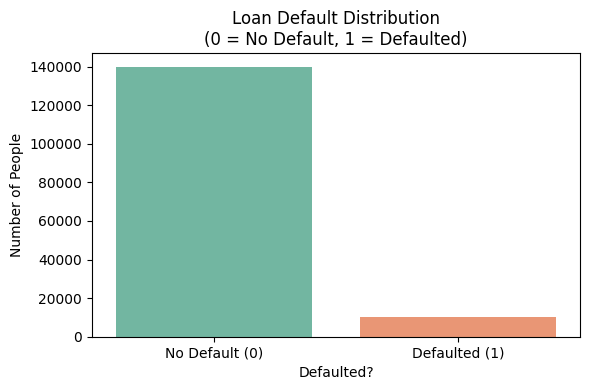

In [7]:
# SeriousDlqin2yrs is our target — 1 means defaulted, 0 means didn't
# We need to understand how many people defaulted vs didn't

target_counts = df['SeriousDlqin2yrs'].value_counts()
print("Target Distribution:")
print(target_counts)
print(f"\nDefault Rate: {(target_counts[1] / len(df) * 100):.2f}%")

# Visualize it
plt.figure(figsize=(6,4))
sns.countplot(x='SeriousDlqin2yrs', data=df, palette='Set2')
plt.title('Loan Default Distribution\n(0 = No Default, 1 = Defaulted)')
plt.xlabel('Defaulted?')
plt.ylabel('Number of People')
plt.xticks([0, 1], ['No Default (0)', 'Defaulted (1)'])
plt.tight_layout()
plt.show()

In [8]:
# Column names like 'NumberOfTime30-59DaysPastDueNotWorse' are too long and
# hard to type repeatedly. We rename them to something clean and short.
# This is a good professional habit — clean column names = readable code

df.rename(columns={
    'SeriousDlqin2yrs': 'target',
    'RevolvingUtilizationOfUnsecuredLines': 'credit_utilization',
    'NumberOfTime30-59DaysPastDueNotWorse': 'late_30_59',
    'DebtRatio': 'debt_ratio',
    'MonthlyIncome': 'monthly_income',
    'NumberOfOpenCreditLinesAndLoans': 'open_loans',
    'NumberOfTimes90DaysLate': 'late_90',
    'NumberRealEstateLoansOrLines': 'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'late_60_89',
    'NumberOfDependents': 'dependents'
}, inplace=True)

# inplace=True means modify the original DataFrame directly
# instead of creating a new one

print("Columns renamed successfully!")
print(df.columns.tolist())

Columns renamed successfully!
['target', 'credit_utilization', 'age', 'late_30_59', 'debt_ratio', 'monthly_income', 'open_loans', 'late_90', 'real_estate_loans', 'late_60_89', 'dependents']


In [12]:
median_income = df['monthly_income'].median()
df['monthly_income'] = df['monthly_income'].fillna(median_income)

print(f"Filled missing MonthlyIncome with median: ${median_income:,.2f}")
print(f"Missing values remaining in monthly_income: {df['monthly_income'].isnull().sum()}")

Filled missing MonthlyIncome with median: $5,400.00
Missing values remaining in monthly_income: 0


In [13]:
# Instead of inplace=True, we explicitly reassign the column
# This is actually the more reliable and modern way to do it in pandas

median_dependents = df['dependents'].median()
df['dependents'] = df['dependents'].fillna(median_dependents)

print(f"Filled missing Dependents with median: {median_dependents}")
print(f"Missing values remaining in dependents: {df['dependents'].isnull().sum()}")

Filled missing Dependents with median: 0.0
Missing values remaining in dependents: 0


In [14]:
# Now we verify the entire dataset has zero missing values
# before moving forward

print("Missing values in each column:")
print(df.isnull().sum())
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing values in each column:
target                0
credit_utilization    0
age                   0
late_30_59            0
debt_ratio            0
monthly_income        0
open_loans            0
late_90               0
real_estate_loans     0
late_60_89            0
dependents            0
dtype: int64

Total missing values in dataset: 0


In [15]:
# Some rows have values that are clearly errors or impossible in real life.
# For example:
# - age of 0 means the data entry was wrong — no one gets a loan at age 0
# - credit_utilization > 1 means someone is using MORE than their credit limit
#   values above 1 are possible but above 2 are almost certainly data errors
# - debt_ratio > 1 means debt is more than income which can happen
#   but extremely high values like 3000+ are clearly errors

print(f"Shape before cleaning: {df.shape}")

df = df[df['age'] > 0]
df = df[df['credit_utilization'] <= 2]
df = df[df['debt_ratio'] < 3000]

print(f"Shape after cleaning: {df.shape}")
print(f"Rows removed: {150000 - df.shape[0]}")

Shape before cleaning: (150000, 11)
Shape after cleaning: (144403, 11)
Rows removed: 5597


In [16]:
# Let's take one final look at the cleaned dataset
# .describe() gives you statistical summary of every column:
# count, mean, min, max, 25th/50th/75th percentile

df.describe().round(2)

,target,credit_utilization,age,late_30_59,debt_ratio,monthly_income,open_loans,late_90,real_estate_loans,late_60_89,dependents
count,144403.00,144403.00,144403.00,144403.00,144403.00,144403.00,144403.00,144403.00,144403.00,144403.00,144403.00
mean,0.07,0.32,52.26,0.43,179.04,6462.61,8.36,0.27,0.98,0.25,0.75
std,0.25,0.36,14.90,4.27,541.69,13130.46,5.12,4.25,1.10,4.23,1.11
min,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.17,3803.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.35,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.55,63.00,0.00,0.73,7500.00,11.00,0.00,2.00,0.00,1.00
max,1.00,2.00,109.00,98.00,2999.00,3008750.00,58.00,98.00,54.00,98.00,20.00


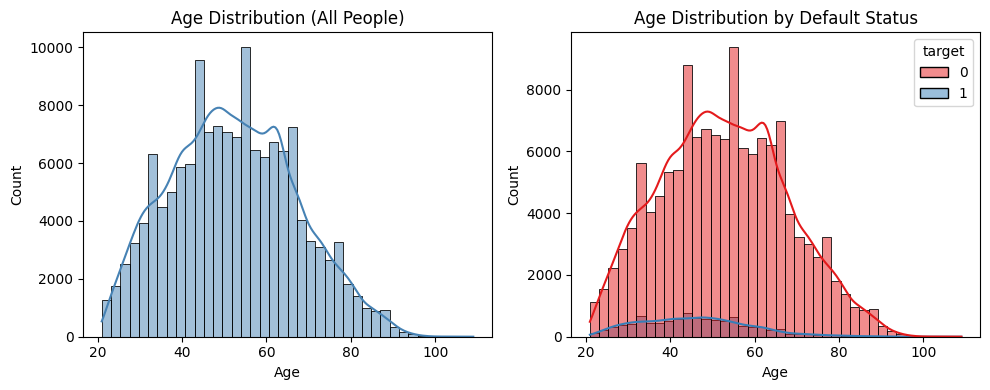

In [17]:
# We want to see the age distribution of people in the dataset
# and compare defaulters vs non-defaulters side by side

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# subplot(1,2,1) means: 1 row, 2 columns, first plot
sns.histplot(df['age'], bins=40, color='steelblue', kde=True)
# bins=40 means divide the data into 40 buckets
# kde=True draws a smooth curve over the histogram
plt.title('Age Distribution (All People)')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='age', hue='target', bins=40, kde=True, palette='Set1')
# hue='target' means color the bars differently based on default status
plt.title('Age Distribution by Default Status')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

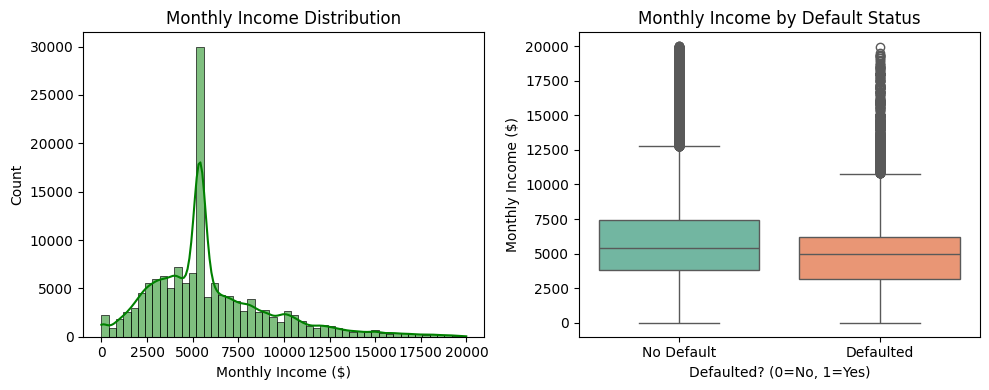

In [18]:
# Income is heavily skewed — most people earn moderate amounts
# but a few earn very high amounts pulling the graph to the right
# We limit the x-axis to $20,000 to see the distribution clearly

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df[df['monthly_income'] < 20000]['monthly_income'], 
             bins=50, color='green', kde=True)
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income ($)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(data=df[df['monthly_income'] < 20000], 
            x='target', y='monthly_income', palette='Set2')
# boxplot shows median, spread, and outliers for each group
plt.title('Monthly Income by Default Status')
plt.xlabel('Defaulted? (0=No, 1=Yes)')
plt.ylabel('Monthly Income ($)')
plt.xticks([0, 1], ['No Default', 'Defaulted'])

plt.tight_layout()
plt.show()

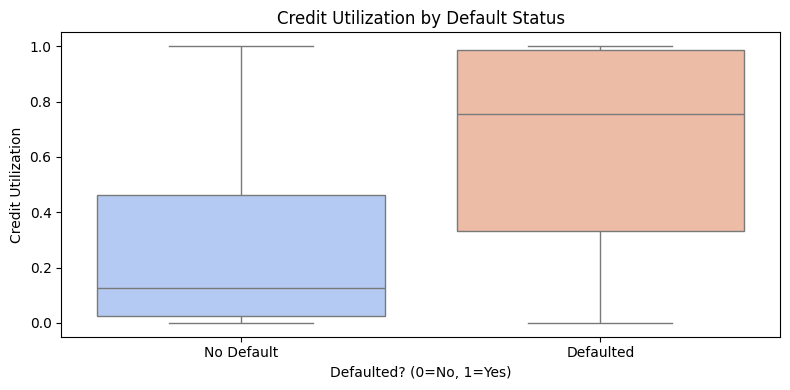

In [19]:
# Credit utilization = how much of your credit limit you're using
# 0.0 means using nothing, 1.0 means maxed out
# Values close to 1 or above suggest financial stress

plt.figure(figsize=(8, 4))
sns.boxplot(data=df[df['credit_utilization'] <= 1], 
            x='target', y='credit_utilization', palette='coolwarm')
plt.title('Credit Utilization by Default Status')
plt.xlabel('Defaulted? (0=No, 1=Yes)')
plt.ylabel('Credit Utilization')
plt.xticks([0, 1], ['No Default', 'Defaulted'])
plt.tight_layout()
plt.show()

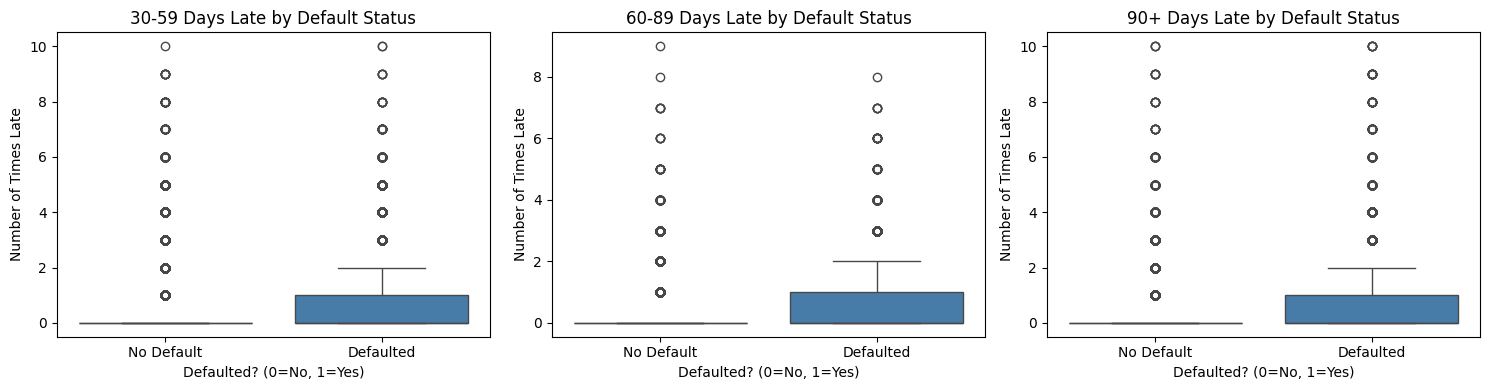

In [20]:
# Number of times someone was late on payments is a strong signal
# If you've been late before, you're more likely to default again

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes, 
                           ['late_30_59', 'late_60_89', 'late_90'],
                           ['30-59 Days Late', '60-89 Days Late', '90+ Days Late']):
    # We cap at 10 because beyond that it's extreme outliers
    temp = df[df[col] <= 10]
    sns.boxplot(data=temp, x='target', y=col, palette='Set1', ax=ax)
    ax.set_title(f'{title} by Default Status')
    ax.set_xlabel('Defaulted? (0=No, 1=Yes)')
    ax.set_ylabel('Number of Times Late')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Default', 'Defaulted'])

plt.tight_layout()
plt.show()

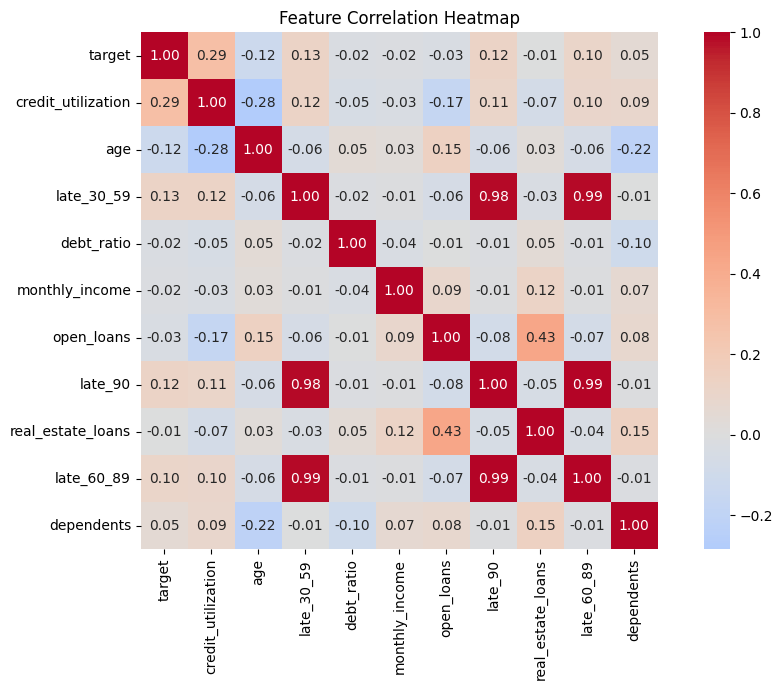

In [21]:
# A correlation heatmap shows how strongly each feature is related
# to every other feature
# Values close to 1 = strong positive relationship
# Values close to -1 = strong negative relationship
# Values close to 0 = no relationship

plt.figure(figsize=(10, 7))
correlation = df.corr()
# .corr() calculates the correlation between every pair of columns

sns.heatmap(correlation, 
            annot=True,        # show the numbers inside each box
            fmt='.2f',         # round to 2 decimal places
            cmap='coolwarm',   # red = positive, blue = negative
            center=0,          # white = no correlation
            square=True)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

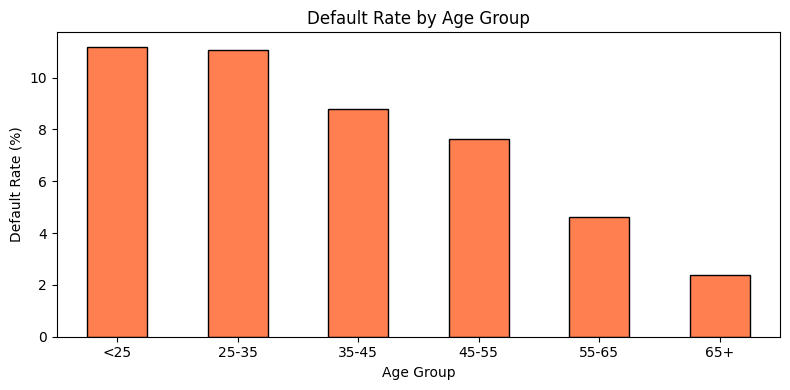

age_group
<25      11.18
25-35    11.07
35-45     8.80
45-55     7.61
55-65     4.62
65+       2.39
Name: target, dtype: float64


In [22]:
# Instead of looking at individual ages, we group people into age buckets
# and calculate the default rate for each group
# This makes the pattern much clearer

# Create age groups
df['age_group'] = pd.cut(df['age'], 
                          bins=[0, 25, 35, 45, 55, 65, 100],
                          labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])
# pd.cut() divides continuous age into labeled categories

default_by_age = df.groupby('age_group')['target'].mean() * 100
# .mean() on a 0/1 column gives the percentage of 1s (defaults) in each group

plt.figure(figsize=(8, 4))
default_by_age.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Default Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(default_by_age.round(2))

In [23]:
# We created age_group just for visualization — we don't want it 
# in our actual model training data so we drop it now

df.drop(columns=['age_group'], inplace=True)
print("age_group column dropped ✅")
print(f"Final shape: {df.shape}")

age_group column dropped ✅
Final shape: (144403, 11)


In [24]:
# We will create 4 new features that capture financial stress
# in ways the original columns don't directly express

# Feature 1: Debt to Income Ratio
# How much of monthly income goes towards debt payments
# High ratio = financially stressed = more likely to default
df['debt_to_income'] = df['debt_ratio'] * df['monthly_income']

# Feature 2: Total Times Late on Any Payment
# Instead of having 3 separate late payment columns,
# we combine them into one total — the model benefits from seeing
# the overall picture of someone's payment behaviour
df['total_late_payments'] = df['late_30_59'] + df['late_60_89'] + df['late_90']

# Feature 3: Income Per Dependent
# A person earning $5000 with 4 dependents is more stressed
# than someone earning $5000 with 0 dependents
# We add 1 to dependents to avoid division by zero
df['income_per_dependent'] = df['monthly_income'] / (df['dependents'] + 1)

# Feature 4: Credit Utilization Bucket
# Instead of a raw number, we categorize utilization into risk levels
# 0 = low risk (using less than 30% of credit)
# 1 = medium risk (using 30-70%)
# 2 = high risk (using more than 70%)
def utilization_bucket(val):
    if val < 0.3:
        return 0
    elif val < 0.7:
        return 1
    else:
        return 2

df['utilization_bucket'] = df['credit_utilization'].apply(utilization_bucket)

print("New features created successfully!")
print(f"Dataset now has {df.shape[1]} columns (was 11)")
print(f"\nNew columns added:")
print("  → debt_to_income")
print("  → total_late_payments")
print("  → income_per_dependent")
print("  → utilization_bucket")

New features created successfully!
Dataset now has 15 columns (was 11)

New columns added:
  → debt_to_income
  → total_late_payments
  → income_per_dependent
  → utilization_bucket


In [25]:
# Always verify your new features after creating them
# Check a sample of rows to make sure the math makes sense

df[['monthly_income', 'debt_ratio', 'debt_to_income',
    'late_30_59', 'late_60_89', 'late_90', 'total_late_payments',
    'dependents', 'income_per_dependent',
    'credit_utilization', 'utilization_bucket']].head(10)

,monthly_income,debt_ratio,debt_to_income,late_30_59,late_60_89,late_90,total_late_payments,dependents,income_per_dependent,credit_utilization,utilization_bucket
1,9120.0,0.802982,7323.197016,2,0,0,2,2.0,3040.000000,0.766127,2
2,2600.0,0.121876,316.878123,0,0,0,0,1.0,1300.000000,0.957151,2
3,3042.0,0.085113,258.914887,1,0,1,2,0.0,3042.000000,0.658180,1
4,3300.0,0.036050,118.963951,0,0,0,0,0.0,3300.000000,0.233810,0
5,63588.0,0.024926,1584.975094,1,0,0,1,0.0,63588.000000,0.907239,2
6,3500.0,0.375607,1314.624392,0,0,0,0,1.0,1750.000000,0.213179,0
8,3500.0,0.209940,734.790059,0,0,0,0,0.0,3500.000000,0.754464,2
9,5400.0,46.000000,248400.000000,0,0,0,0,0.0,5400.000000,0.116951,0
10,23684.0,0.606291,14359.393699,0,0,0,0,2.0,7894.666667,0.189169,0
11,2500.0,0.309476,773.690525,0,0,0,0,0.0,2500.000000,0.644226,1


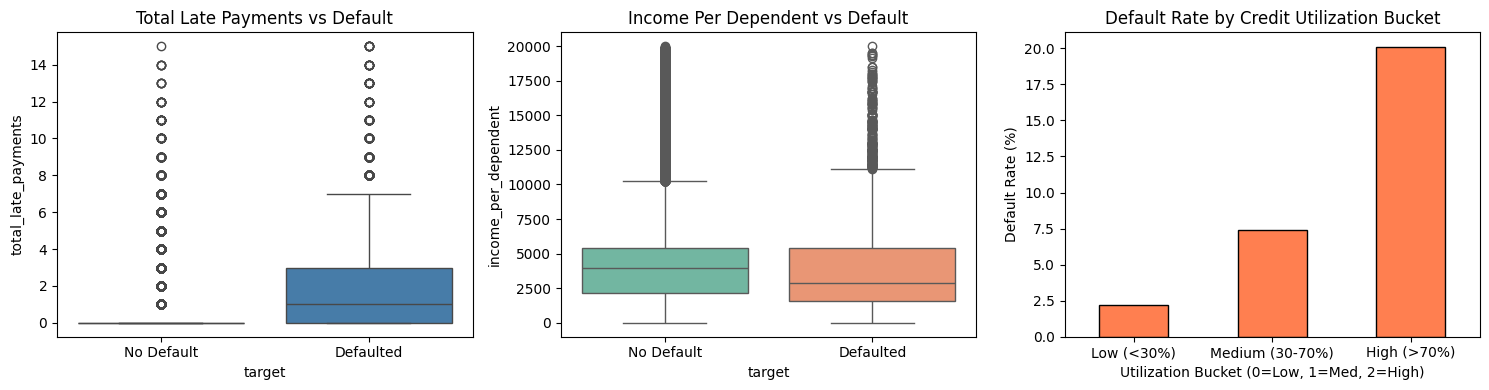

In [26]:
# Let's quickly check if our new features actually have
# a relationship with the target (defaulting)
# If they do, they'll help the model

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total late payments vs default
sns.boxplot(data=df[df['total_late_payments'] <= 15],
            x='target', y='total_late_payments', 
            palette='Set1', ax=axes[0])
axes[0].set_title('Total Late Payments vs Default')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Default', 'Defaulted'])

# Income per dependent vs default
sns.boxplot(data=df[df['income_per_dependent'] < 20000],
            x='target', y='income_per_dependent',
            palette='Set2', ax=axes[1])
axes[1].set_title('Income Per Dependent vs Default')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Default', 'Defaulted'])

# Utilization bucket vs default rate
default_by_bucket = df.groupby('utilization_bucket')['target'].mean() * 100
default_by_bucket.plot(kind='bar', color='coral', 
                        edgecolor='black', ax=axes[2])
axes[2].set_title('Default Rate by Credit Utilization Bucket')
axes[2].set_xlabel('Utilization Bucket (0=Low, 1=Med, 2=High)')
axes[2].set_ylabel('Default Rate (%)')
axes[2].set_xticklabels(['Low (<30%)', 'Medium (30-70%)', 'High (>70%)'], 
                          rotation=0)

plt.tight_layout()
plt.show()

In [27]:
# Now we define exactly which columns will go into the model
# X = features (inputs to the model)
# y = target (what we want to predict)

# We drop 'target' from X because that's what we're predicting
# We keep all original and newly engineered features

feature_columns = [
    'credit_utilization', 'age', 'late_30_59', 'debt_ratio',
    'monthly_income', 'open_loans', 'late_90', 'real_estate_loans',
    'late_60_89', 'dependents', 'debt_to_income', 
    'total_late_payments', 'income_per_dependent', 'utilization_bucket'
]

X = df[feature_columns]
y = df['target']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns:\n{feature_columns}")

Features (X) shape: (144403, 14)
Target (y) shape: (144403,)

Feature columns:
['credit_utilization', 'age', 'late_30_59', 'debt_ratio', 'monthly_income', 'open_loans', 'late_90', 'real_estate_loans', 'late_60_89', 'dependents', 'debt_to_income', 'total_late_payments', 'income_per_dependent', 'utilization_bucket']


In [28]:
# We split the data into two parts:
# Training set (80%) — the model learns from this
# Test set (20%) — we use this to evaluate how well it learned
# The model NEVER sees the test set during training

# random_state=42 means the split will be the same every time you run it
# stratify=y means maintain the same 7%/93% ratio in both train and test sets
# Without stratify, by random chance you might get unequal splits

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nDefault rate in training set: {(y_train.mean()*100):.2f}%")
print(f"Default rate in test set: {(y_test.mean()*100):.2f}%")

Training set size: 115522 rows
Test set size: 28881 rows

Class distribution in training set:
target
0    107790
1      7732
Name: count, dtype: int64

Default rate in training set: 6.69%
Default rate in test set: 6.69%


In [29]:
# Feature scaling means bringing all columns to the same scale
# For example, 'age' ranges from 20-90 but 'monthly_income' ranges from 0-50000
# Without scaling, the model thinks income is more important just because
# its numbers are bigger — which is wrong

# StandardScaler transforms each column so it has:
# mean = 0 and standard deviation = 1
# Now every feature is on equal footing

scaler = StandardScaler()

# IMPORTANT: We fit the scaler ONLY on training data
# then use it to transform both train and test
# Why? Because in real life you don't know the test data in advance
# Fitting on test data would be "cheating" — called data leakage

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done ✅")
print(f"Training data mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Training data std (should be ~1): {X_train_scaled.std():.4f}")

Scaling done ✅
Training data mean (should be ~0): 0.0000
Training data std (should be ~1): 1.0000


In [30]:
# SMOTE creates synthetic examples of the minority class (defaulters)
# It works by:
# 1. Taking a defaulter
# 2. Finding its nearest neighbours (other similar defaulters)
# 3. Creating a new synthetic point somewhere between them
# This is smarter than just copying existing defaulters

# random_state=42 for reproducibility
smote = SMOTE(random_state=42)

# We apply SMOTE only on the SCALED training data
# Never on test data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE applied successfully ✅")
print(f"\nBefore SMOTE:")
print(f"  No Default (0): {(y_train == 0).sum()}")
print(f"  Defaulted  (1): {(y_train == 1).sum()}")
print(f"\nAfter SMOTE:")
print(f"  No Default (0): {(y_train_resampled == 0).sum()}")
print(f"  Defaulted  (1): {(y_train_resampled == 1).sum()}")

SMOTE applied successfully ✅

Before SMOTE:
  No Default (0): 107790
  Defaulted  (1): 7732

After SMOTE:
  No Default (0): 107790
  Defaulted  (1): 107790


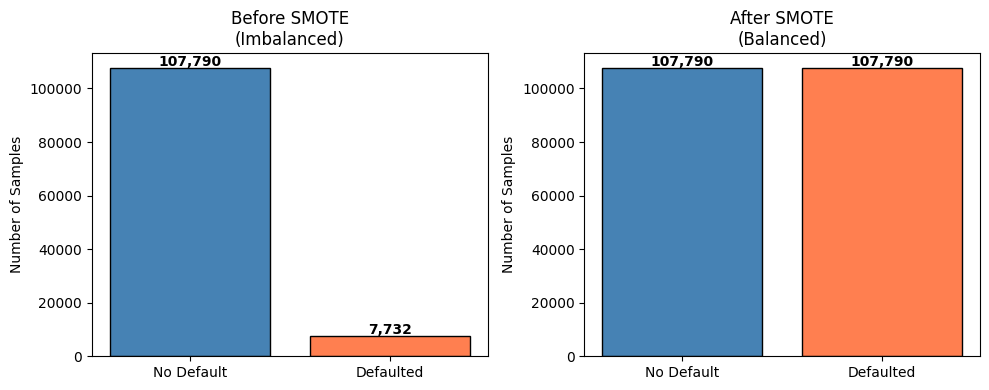

In [31]:
# Let's visualize the before and after to make it crystal clear

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
axes[0].bar(['No Default', 'Defaulted'], 
             [( y_train == 0).sum(), (y_train == 1).sum()],
             color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Before SMOTE\n(Imbalanced)')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate([(y_train == 0).sum(), (y_train == 1).sum()]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# After SMOTE
axes[1].bar(['No Default', 'Defaulted'],
             [(y_train_resampled == 0).sum(), (y_train_resampled == 1).sum()],
             color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('After SMOTE\n(Balanced)')
axes[1].set_ylabel('Number of Samples')
for i, v in enumerate([(y_train_resampled == 0).sum(), (y_train_resampled == 1).sum()]):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# Logistic Regression is our baseline model
# max_iter=1000 gives it enough iterations to converge (find its best solution)
# It will train very fast — just a few seconds

print("Training Logistic Regression...")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)
# .fit() is where actual learning happens
# The model looks at features and labels and finds the best parameters

lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
# predict_proba gives probability of each class for each row
# [:, 1] takes only the probability of class 1 (defaulting)
# We use probabilities instead of hard 0/1 predictions for AUC-ROC scoring

lr_auc = roc_auc_score(y_test, lr_pred_proba)

print(f"Logistic Regression AUC-ROC: {lr_auc:.4f}")
print("Done ✅")

Training Logistic Regression...
Logistic Regression AUC-ROC: 0.8234
Done ✅


In [33]:
# Random Forest builds 100 decision trees (n_estimators=100)
# n_jobs=-1 uses all CPU cores to train in parallel — faster training
# This will take 1-2 minutes

print("Training Random Forest (this may take 1-2 minutes)...")

rf_model = RandomForestClassifier(
    n_estimators=100,    # build 100 trees
    max_depth=10,        # each tree can go at most 10 levels deep
                         # limiting depth prevents overfitting
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf_model.fit(X_train_resampled, y_train_resampled)

rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred_proba)

print(f"Random Forest AUC-ROC: {rf_auc:.4f}")
print("Done ✅")

Training Random Forest (this may take 1-2 minutes)...
Random Forest AUC-ROC: 0.8588
Done ✅


In [34]:
# XGBoost is our most powerful model
# It builds trees sequentially, each one fixing the previous one's errors
# This will take 2-3 minutes

print("Training XGBoost (this may take 2-3 minutes)...")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,        # build 200 sequential trees
    max_depth=5,             # each tree is relatively shallow
    learning_rate=0.1,       # how much each tree corrects the previous one
                             # lower = more careful learning = better results
    subsample=0.8,           # each tree uses 80% of randomly selected rows
                             # adds randomness which reduces overfitting
    colsample_bytree=0.8,    # each tree uses 80% of randomly selected features
    scale_pos_weight=1,      # since we used SMOTE data is already balanced
    random_state=42,
    eval_metric='auc',
    verbosity=0              # suppress training logs
)
xgb_model.fit(X_train_resampled, y_train_resampled)

xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

print(f"XGBoost AUC-ROC: {xgb_auc:.4f}")
print("Done ✅")

Training XGBoost (this may take 2-3 minutes)...
XGBoost AUC-ROC: 0.8492
Done ✅


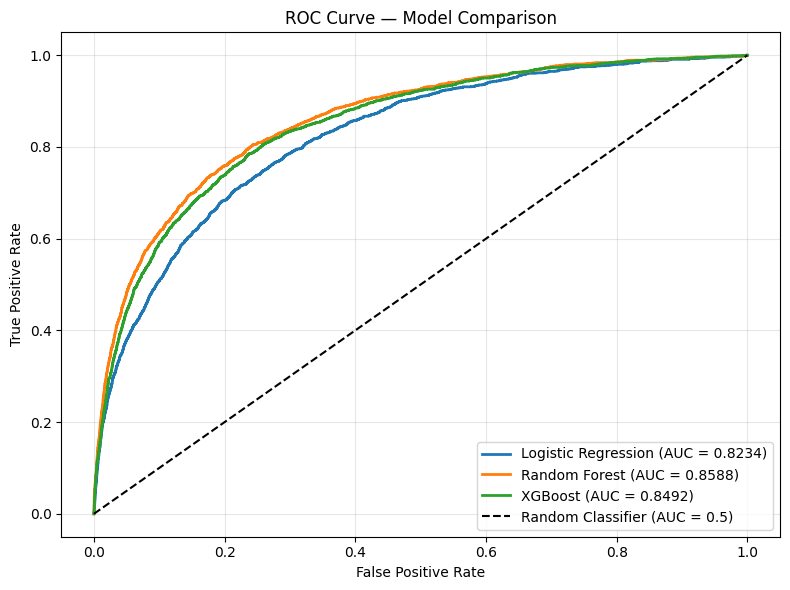


Model                        AUC-ROC
Logistic Regression           0.8234
Random Forest                 0.8588
XGBoost                       0.8492


In [41]:
# Now we compare all three models side by side
# Both numerically and visually using ROC curves

# ROC curve plots True Positive Rate vs False Positive Rate
# at different threshold levels
# The higher the curve bows towards the top-left corner, the better
# AUC = Area Under the Curve — higher is better, max is 1.0

plt.figure(figsize=(8, 6))

models = {
    'Logistic Regression': (lr_model, lr_pred_proba, lr_auc),
    'Random Forest': (rf_model, rf_pred_proba, rf_auc),
    'XGBoost': (xgb_model, xgb_pred_proba, xgb_auc)
}

for name, (model, pred_proba, auc) in models.items():
    fpr, tpr, _ = roc_curve(y_test, pred_proba)
    # fpr = false positive rate (predicted default but wasn't)
    # tpr = true positive rate (correctly predicted default)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

# The diagonal line represents a random/useless model (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*45)
print(f"{'Model':<25} {'AUC-ROC':>10}")
print("="*45)
for name, (_, _, auc) in models.items():
    print(f"{name:<25} {auc:>10.4f}")
print("="*45)

Random Forest Detailed Performance:
              precision    recall  f1-score   support

  No Default       0.97      0.91      0.94     26948
   Defaulted       0.32      0.60      0.41      1933

    accuracy                           0.89     28881
   macro avg       0.64      0.75      0.68     28881
weighted avg       0.93      0.89      0.90     28881



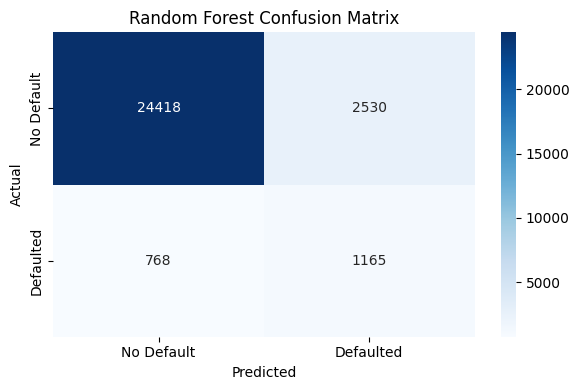

In [43]:
# AUC tells us overall performance but we also want to see
# precision, recall, and f1-score broken down by class

# We need to convert probabilities to actual 0/1 predictions
# 0.5 threshold means: if probability > 50% predict default

rf_pred = (rf_pred_proba >= 0.5).astype(int)

print("Random Forest Detailed Performance:")
print("="*50)
print(classification_report(y_test, rf_pred,
                             target_names=['No Default', 'Defaulted']))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Defaulted'],
            yticklabels=['No Default', 'Defaulted'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [45]:
print("Initializing SHAP explainer...")

explainer = shap.TreeExplainer(rf_model)

# Take a sample of 1000 rows from test set
# Calculating for all 28,000 rows would take too long
X_test_sample = pd.DataFrame(X_test_scaled, columns=feature_columns).sample(
    1000, random_state=42
)

print("Calculating SHAP values (this may take 2-3 minutes)...")
shap_values = explainer.shap_values(X_test_sample)

# Fix for newer SHAP versions
# New versions return shape (n_samples, n_features, n_classes)
# instead of a list — we extract class 1 (default)
shap_values_default = shap_values[:, :, 1]

print("SHAP values calculated ✅")
print(f"Shape of SHAP values: {shap_values_default.shape}")
# Should print (1000, 14)

Initializing SHAP explainer...
Calculating SHAP values (this may take 2-3 minutes)...
SHAP values calculated ✅
Shape of SHAP values: (1000, 14)


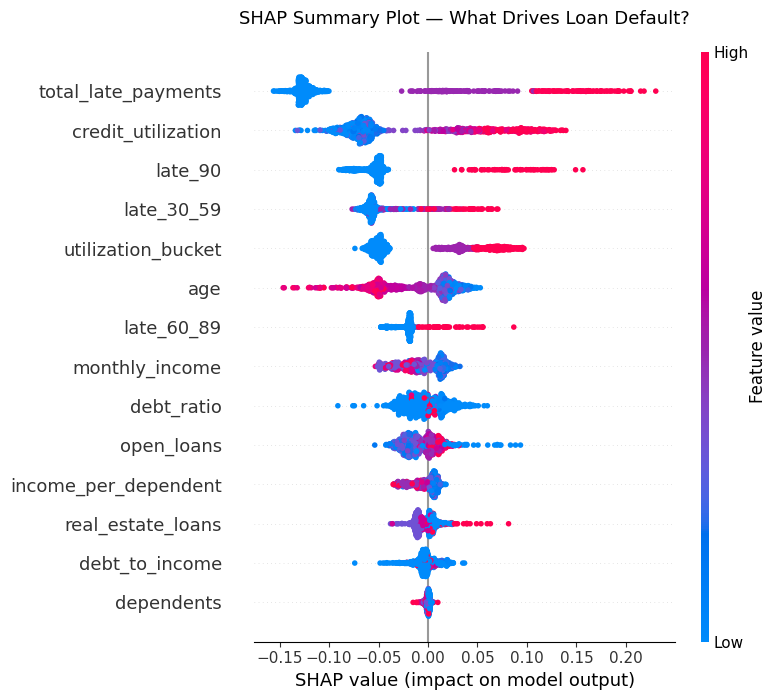

In [46]:
# The summary plot is the most important SHAP visualization
# It shows:
# - Which features matter most OVERALL (y-axis, ranked top to bottom)
# - How strongly each feature pushes predictions (x-axis)
# - Whether high or low values increase default risk (color)
#   Red = high feature value, Blue = low feature value

plt.figure()
shap.summary_plot(
    shap_values_default,
    X_test_sample,
    plot_type='dot',
    max_display=14,
    show=False
)
plt.title('SHAP Summary Plot — What Drives Loan Default?',
          fontsize=13, pad=20)
plt.tight_layout()
plt.show()

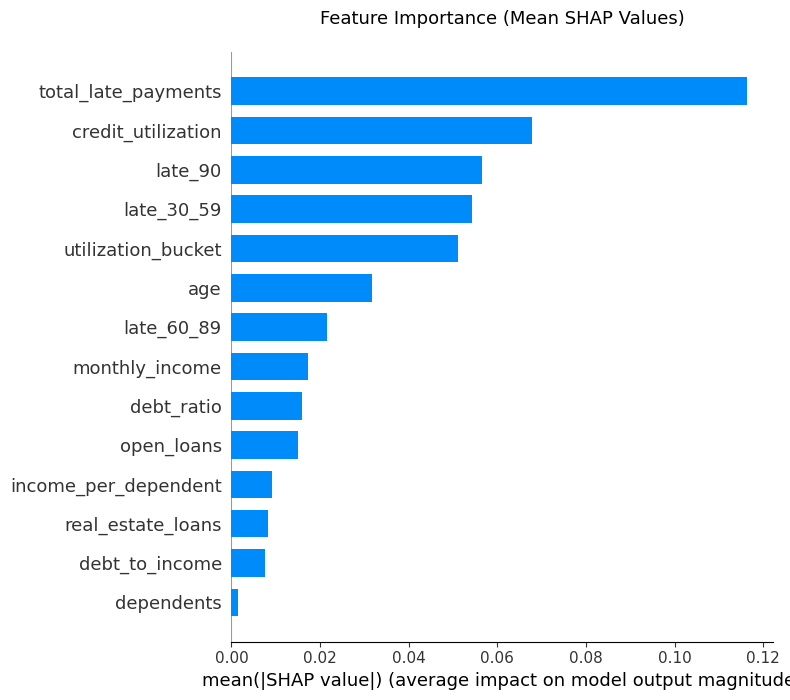

In [47]:
# The bar plot shows the average impact of each feature
# Simpler than the summary plot — easier to explain to non-technical people
# This is what you'd show a manager or interviewer

plt.figure()
shap.summary_plot(
    shap_values_default,
    X_test_sample,
    plot_type='bar',
    max_display=14,
    show=False
)
plt.title('Feature Importance (Mean SHAP Values)', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

In [48]:
# This is the most powerful part — explaining a SINGLE person's prediction
# This is exactly what a bank would show a customer who was rejected

person_index = 0
person_shap = shap_values_default[person_index]
person_default_prob = rf_model.predict_proba(
    X_test_sample.iloc[[person_index]]
)[0][1]

print(f"Person #{person_index} Analysis:")
print(f"Predicted Default Probability: {person_default_prob:.2%}")
print(f"\nFactors pushing towards default (+) or away (-):")
print("-" * 55)

# Sort features by absolute SHAP value — most impactful first
feature_shap_pairs = sorted(
    zip(feature_columns, person_shap),
    key=lambda x: abs(x[1]),
    reverse=True
)

for feature, shap_val in feature_shap_pairs:
    direction = "↑ INCREASES default risk" if shap_val > 0 else "↓ DECREASES default risk"
    print(f"{feature:<25} SHAP: {shap_val:>8.4f}  →  {direction}")

Person #0 Analysis:
Predicted Default Probability: 27.52%

Factors pushing towards default (+) or away (-):
-------------------------------------------------------
total_late_payments       SHAP:  -0.1233  →  ↓ DECREASES default risk
late_30_59                SHAP:  -0.0627  →  ↓ DECREASES default risk
late_90                   SHAP:  -0.0519  →  ↓ DECREASES default risk
income_per_dependent      SHAP:  -0.0343  →  ↓ DECREASES default risk
age                       SHAP:   0.0334  →  ↑ INCREASES default risk
monthly_income            SHAP:  -0.0327  →  ↓ DECREASES default risk
credit_utilization        SHAP:   0.0272  →  ↑ INCREASES default risk
utilization_bucket        SHAP:   0.0240  →  ↑ INCREASES default risk
late_60_89                SHAP:  -0.0195  →  ↓ DECREASES default risk
debt_to_income            SHAP:   0.0134  →  ↑ INCREASES default risk
debt_ratio                SHAP:   0.0086  →  ↑ INCREASES default risk
real_estate_loans         SHAP:  -0.0060  →  ↓ DECREASES default r

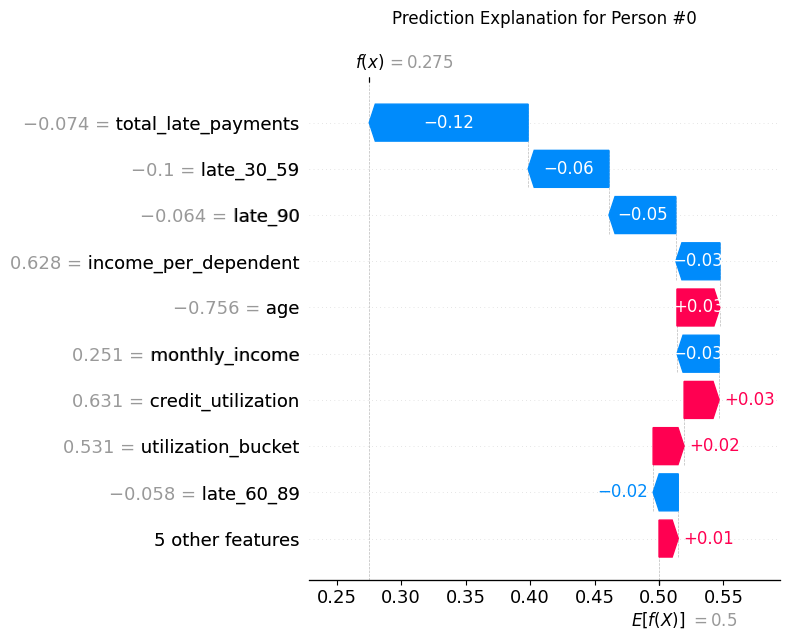

In [49]:
# The waterfall plot is the most beautiful individual explanation
# It shows how we start from the average prediction and
# each feature moves us up or down to reach the final prediction

shap_explanation = shap.Explanation(
    values=shap_values_default[person_index],
    base_values=explainer.expected_value[1],
    data=X_test_sample.iloc[person_index],
    feature_names=feature_columns
)

shap.plots.waterfall(shap_explanation, show=False)
plt.title(f'Prediction Explanation for Person #{person_index}', pad=20)
plt.tight_layout()
plt.show()

In [50]:
import joblib

# Save the model and scaler to files
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved ✅")
print("Scaler saved ✅")

Model saved ✅
Scaler saved ✅
